# EDA QA dataset cho RAG
Phân tích câu hỏi, answerability, QA type, source articles và độ khó tiềm năng đối với retrieval/generation.

In [1]:
from pathlib import Path
import json, ast, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "Dataset" / "QA_Claude").exists():
    ROOT = ROOT.parent
if not (ROOT / "Dataset" / "QA_Claude").exists():
    raise FileNotFoundError(f"Khong tim thay project root tu cwd: {Path.cwd()}")
QA_PATH=ROOT/'Dataset'/'QA_Claude'/'QA_output.jsonl'
CORPUS=ROOT/'Dataset'/'Create_QA_Vietonline'/'VietOnlineNews'
if not CORPUS.exists():
    CORPUS=ROOT/'Dataset'/'Create_QA_Vietonline'/'VietOnlineNews_CSV'
rows=[json.loads(line) for line in QA_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
qa=pd.DataFrame(rows)
def as_list(x):
    if isinstance(x,list): return x
    if x is None or (isinstance(x,float) and np.isnan(x)): return []
    if isinstance(x,str):
        try:
            y=ast.literal_eval(x)
            return y if isinstance(y,list) else [y]
        except Exception: return [z.strip() for z in x.split(';') if z.strip()]
    return [x]
qa['question']=qa.get('question','').fillna('').astype(str)
qa['question_words']=qa['question'].str.split().str.len()
qa['question_chars']=qa['question'].str.len()
qa['qa_type']=qa.get('qa_type','unknown').fillna('unknown').astype(str)
qa['is_possible_norm']=qa.get('is_possible',pd.Series([np.nan]*len(qa))).map(lambda x: str(x).lower() if pd.notna(x) else 'unknown')
qa['source_ids_norm']=qa.get('source_article_ids',qa.get('article_id',pd.Series([None]*len(qa)))).map(as_list)
qa['num_source_articles']=qa['source_ids_norm'].str.len()
if 'answers' in qa:
    qa['answer_text']=qa['answers'].map(lambda x: ' '.join(map(str,as_list(x))) if not isinstance(x,dict) else str(x) )
else: qa['answer_text']=''
qa['answer_words']=qa['answer_text'].fillna('').str.split().str.len()
qa['answerable']=qa['is_possible_norm'].isin(['true','1','yes'])
display(qa.head())
print('Rows:',len(qa),'| unique ids:',qa.get('id',pd.Series(dtype=str)).nunique(),'| duplicate questions:',qa['question'].duplicated().sum())

,id,article_id,question,answers,is_possible,plausible_answers,qa_type,question_words,question_chars,is_possible_norm,source_ids_norm,num_source_articles,answer_text,answer_words,answerable
0,211640_1,211640,Những loại nội tạng động vật nào được khuyến c...,"[Gan, thận, lòng và dạ dày là các loại nội tạn...",True,[Tất cả nội tạng động vật nói chung đều nên tr...,factoid,21,97,true,[211640],1,"Gan, thận, lòng và dạ dày là các loại nội tạng...",35,True
1,211640_2,211640,Quan niệm cho rằng thịt dê là thủ phạm duy nhấ...,[Thịt dê đúng là thịt đỏ có hàm lượng purin ca...,True,[Thịt dê thậm chí có thể chứa ít purin hơn một...,event_summary,21,92,true,[211640],1,Thịt dê đúng là thịt đỏ có hàm lượng purin cao...,66,True
2,211640_3,211640,Tại sao nước dùng hầm xương hoặc nước lẩu lại ...,[Khi ninh hầm lâu hoặc nhúng lẩu nhiều nguyên ...,True,[Nước dùng hầm lâu còn có thể chứa nhiều chất ...,cause_effect,16,70,true,[211640],1,Khi ninh hầm lâu hoặc nhúng lẩu nhiều nguyên l...,57,True
3,211640_4,211640,Hàm lượng purin trong cá nhỏ và nội tạng động ...,[Nội tạng động vật chứa lượng purin gấp 2-3 lầ...,True,[Mức purin cụ thể còn phụ thuộc vào cách chế b...,comparison,21,95,true,[211640],1,Nội tạng động vật chứa lượng purin gấp 2-3 lần...,46,True
4,211640_5,211640,Đúng hay sai: 'Chỉ cần bỏ thịt dê và chuyển sa...,"[Sai. Nhiều loại hải sản như cá nhỏ (cá trích,...",True,[Một số loại hải sản có purin thấp hơn như cá ...,claim_verification,22,95,true,[211640],1,"Sai. Nhiều loại hải sản như cá nhỏ (cá trích, ...",72,True


Rows: 152 | unique ids: 152 | duplicate questions: 0


## Phân bố QA type, answerability và số bài nguồn

,questions,avg_question_words,avg_answer_words,answerable_rate,avg_sources
qa_type,,,,,
cause_effect,21,21.619,43.762,1.000,1.0
claim_verification,5,22.200,47.800,1.000,1.0
comparison,5,19.800,39.400,1.000,1.0
entity_role,14,20.214,57.000,1.000,1.0
event_summary,20,21.400,68.050,1.000,1.0
factoid,20,19.800,19.850,1.000,1.0
multi_doc_comparison,42,53.333,80.881,0.667,3.0
timeline,10,54.300,0.000,0.100,3.0
unanswerable,15,21.800,0.000,0.000,1.0


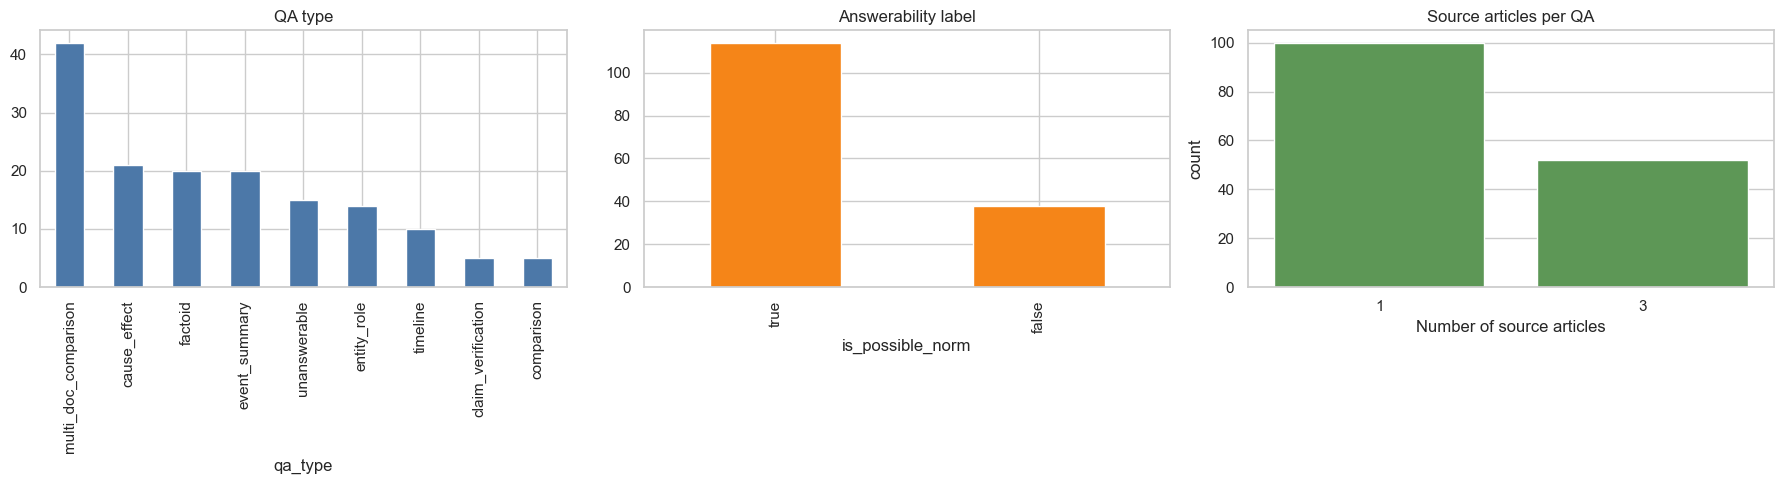

In [2]:
sns.set_theme(style='whitegrid')
fig,ax=plt.subplots(1,3,figsize=(18,5))
qa['qa_type'].value_counts().plot.bar(ax=ax[0],color='#4C78A8',title='QA type')
qa['is_possible_norm'].value_counts().plot.bar(ax=ax[1],color='#F58518',title='Answerability label')
sns.countplot(data=qa,x='num_source_articles',ax=ax[2],color='#54A24B'); ax[2].set_title('Source articles per QA'); ax[2].set_xlabel('Number of source articles')
plt.tight_layout()
display(qa.groupby('qa_type').agg(questions=('question','size'),avg_question_words=('question_words','mean'),avg_answer_words=('answer_words','mean'),answerable_rate=('answerable','mean'),avg_sources=('num_source_articles','mean')).round(3))

## Độ dài câu hỏi/câu trả lời và query difficulty proxies

,question_words,question_chars,answer_words,num_source_articles
count,152.00,152.00,152.00,152.00
mean,32.11,145.66,48.08,1.68
std,17.37,78.66,45.95,0.95
min,12.00,54.00,0.00,1.00
50%,24.00,109.50,43.50,1.00
90%,59.00,269.50,124.90,3.00
95%,66.90,303.15,137.90,3.00
99%,76.98,349.00,165.92,3.00
max,81.00,358.00,192.00,3.00


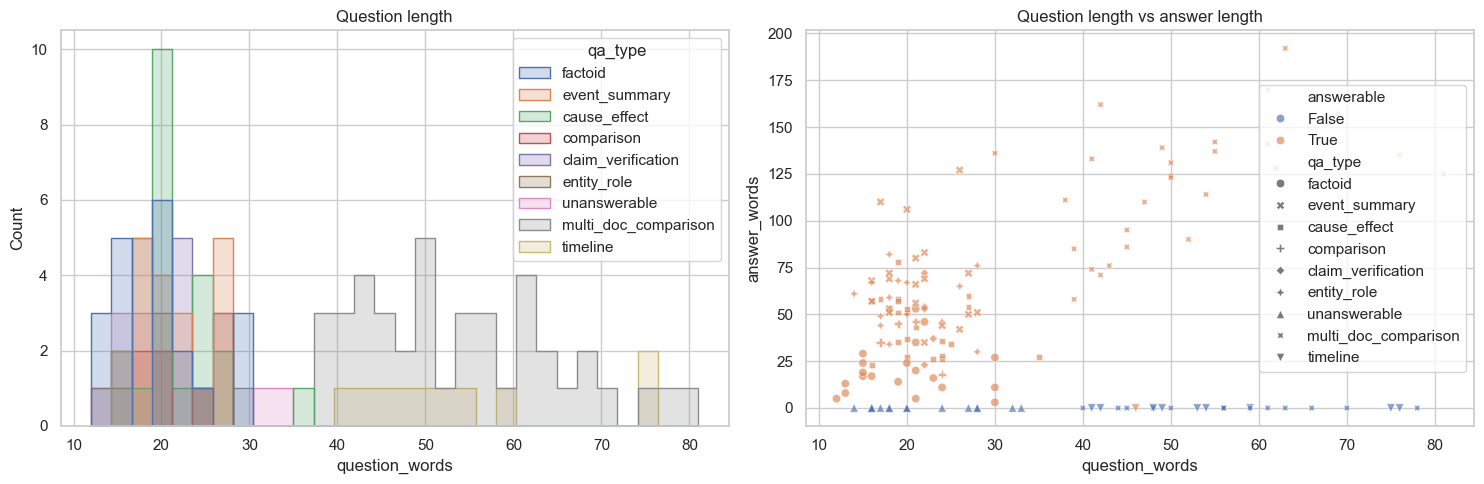

In [3]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.histplot(data=qa,x='question_words',hue='qa_type',bins=30,element='step',common_norm=False,ax=ax[0]); ax[0].set_title('Question length')
sns.scatterplot(data=qa,x='question_words',y='answer_words',hue='answerable',style='qa_type',alpha=.65,ax=ax[1]); ax[1].set_title('Question length vs answer length')
plt.tight_layout()
display(qa[['question_words','question_chars','answer_words','num_source_articles']].describe(percentiles=[.5,.9,.95,.99]).round(2))

## Kiểm tra liên kết QA với corpus và phát hiện QA bất thường

In [4]:
ids=set()
for split in ['train','validation','test']:
    for name in [f'{split}_new.csv', f'{split}.csv']:
        p=CORPUS/name
        if p.exists():
            ids.update(pd.read_csv(p,usecols=['id'])['id'].astype(str))
            break
qa['missing_source_id']=qa['source_ids_norm'].map(lambda xs:any(str(x) not in ids for x in xs))
print('QA có source article không tồn tại:',int(qa['missing_source_id'].sum()))
print('Câu hỏi rỗng:',int((qa['question'].str.strip()=='').sum()))
print('Answerable nhưng không có source:',int((qa['answerable'] & qa['num_source_articles'].eq(0)).sum()))
print('Potential duplicates:')
display(qa[qa['question'].duplicated(False)].sort_values('question')[['id','question','qa_type','source_ids_norm']].head(20))
print('Longest questions:')
display(qa.nlargest(10,'question_words')[['id','question','question_words','qa_type','num_source_articles']])

QA có source article không tồn tại: 0
Câu hỏi rỗng: 0
Answerable nhưng không có source: 0
Potential duplicates:


,id,question,qa_type,source_ids_norm


Longest questions:


,id,question,question_words,qa_type,num_source_articles
100,cross_0_1,Theo các bài báo về phong thủy xây nhà năm Quý...,81,multi_doc_comparison,3
147,cross_23_2,"Xét về mặt giá bán, liệu mức giá của các mẫu x...",78,multi_doc_comparison,3
106,cross_3_1,So sánh chính sách thị thực của Trung Quốc đối...,76,multi_doc_comparison,3
139,cross_19_2,"Theo trình tự thời gian, hãy sắp xếp các sự ki...",76,timeline,3
117,cross_8_2,Xét theo dòng thời gian từ iPhone 17 Pro (2025...,75,timeline,3
101,cross_0_2,So sánh quan điểm của ba bài báo về các yếu tố...,70,multi_doc_comparison,3
114,cross_7_1,So sánh vai trò của các nhà thiết kế Việt Nam ...,69,multi_doc_comparison,3
137,cross_18_2,Xét toàn bộ các trận đấu được đề cập trong cả ...,68,multi_doc_comparison,3
107,cross_3_2,"Dựa trên thông tin từ các bài báo, liệu chính ...",66,multi_doc_comparison,3
127,cross_13_2,Trong trường hợp cha mẹ cho con 15 tuổi vay ti...,63,multi_doc_comparison,3


## Keyword question type và export features

In [5]:
patterns={'who':r'\b(ai|người nào|nhân vật nào)\b','when':r'\b(khi nào|bao giờ|năm nào|ngày nào)\b','where':r'\b(ở đâu|tại đâu|nơi nào)\b','how_many':r'\b(bao nhiêu|mấy|số lượng)\b','why':r'\b(tại sao|vì sao|nguyên nhân)\b','what':r'\b(là gì|những gì|điều gì)\b'}
for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)
keyword_counts=pd.DataFrame({'feature':list(patterns),'count':[int(qa[f'keyword_{k}'].sum()) for k in patterns]})
display(keyword_counts.sort_values('count',ascending=False))
out=ROOT/'reports'/'eda_outputs'; out.mkdir(exist_ok=True)
cols=['id','qa_type','question','question_words','question_chars','answer_words','num_source_articles','answerable','missing_source_id']+[f'keyword_{k}' for k in patterns]
qa[cols].to_csv(out/'qa_rag_features.csv',index=False)
print('Saved:',out/'qa_rag_features.csv')

C:\Users\luong\AppData\Local\Temp\ipykernel_2608\3766365358.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)
C:\Users\luong\AppData\Local\Temp\ipykernel_2608\3766365358.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)
C:\Users\luong\AppData\Local\Temp\ipykernel_2608\3766365358.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)
C:\Users\luong\AppData\Local\Temp\ipykernel_2608\3766365358.p

,feature,count
5,what,17
3,how_many,13
4,why,13
0,who,11
1,when,0
2,where,0


Saved: C:\Khai thác dữ liệu văn bản\Text-Mining---RAG-on-News\reports\eda_outputs\qa_rag_features.csv


## Coverage category c?a QA so v?i corpus
Join QA v?i article source ?? ki?m tra QA ?? ph? h?t category ch?a v? t? l? theo category.

,category,corpus_articles,corpus_pct,qa_questions,qa_pct
3,Giải trí,2270,15.58,24,15.79
10,Thời sự,1485,10.19,19,12.50
2,Giáo dục,1241,8.52,14,9.21
4,Khoa học công nghệ,1089,7.47,14,9.21
11,Xe,1045,7.17,14,9.21
7,Sức khỏe,928,6.37,14,9.21
0,Bất động sản,379,2.60,14,9.21
5,Kinh doanh,1853,12.72,9,5.92
9,Thể thao,1760,12.08,9,5.92
1,Du lịch,488,3.35,9,5.92


Corpus categories: 13 | QA source categories: 13
Categories in corpus but not QA: []


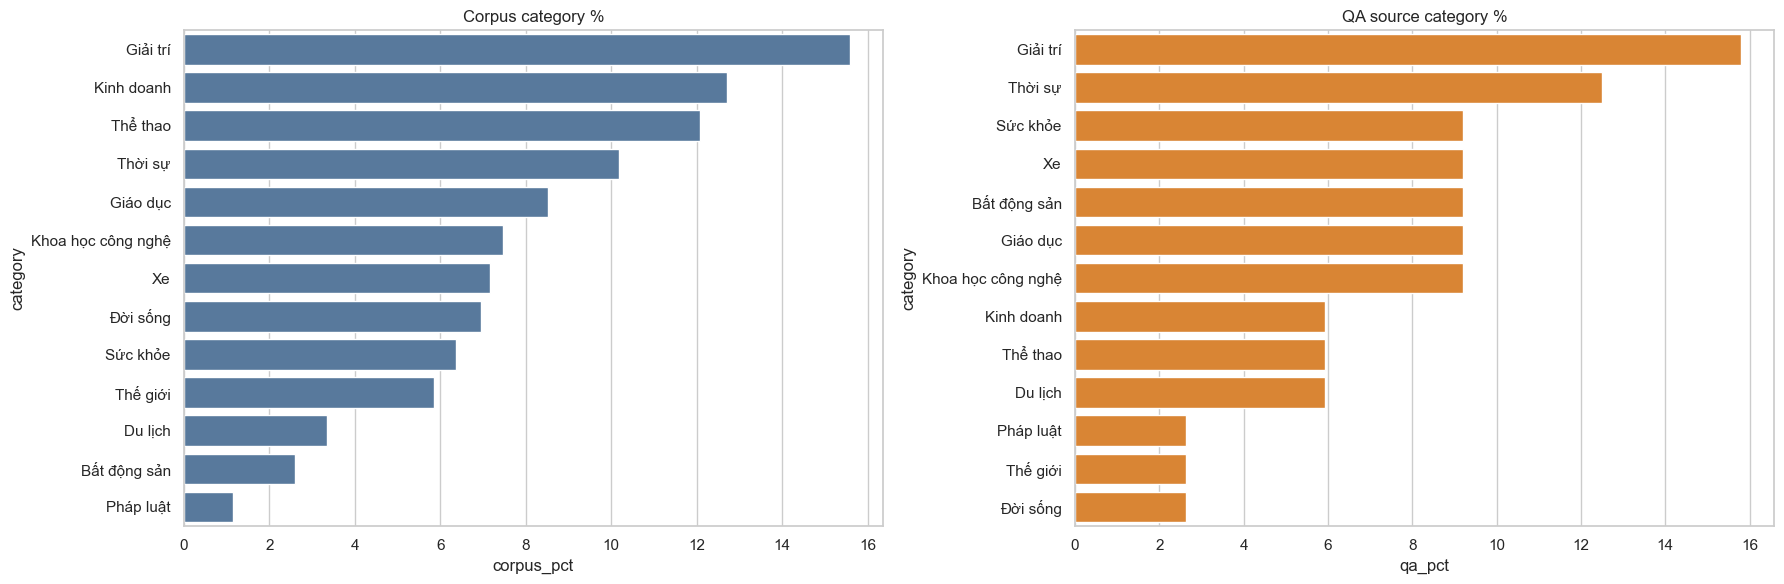

In [6]:
parts=[]
for split in ['train','validation','test']:
    for name in [f'{split}_new.csv', f'{split}.csv']:
        p=CORPUS/name
        if p.exists():
            x=pd.read_csv(p); x['split']=split; parts.append(x)
            break
news=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()
for c in ['id','title','description','content','category']:
    if c not in news: news[c]=''
news['id_str']=news['id'].astype(str)
news['category']=news['category'].fillna('(missing)').astype(str)
news['content']=news['content'].fillna('').astype(str)
id_to_category=dict(zip(news['id_str'],news['category']))
id_to_content=dict(zip(news['id_str'],news['content']))
id_to_title=dict(zip(news['id_str'],news['title'].fillna('').astype(str)))
qa['source_category']=qa['source_ids_norm'].map(lambda xs:'; '.join(sorted({id_to_category.get(str(x),'(missing_source)') for x in xs})) if xs else '(no_source)')
corpus_cat=news['category'].value_counts().rename_axis('category').reset_index(name='corpus_articles')
corpus_cat['corpus_pct']=(corpus_cat['corpus_articles']/max(len(news),1)*100).round(2)
qa_cat=qa['source_category'].value_counts().rename_axis('category').reset_index(name='qa_questions')
qa_cat['qa_pct']=(qa_cat['qa_questions']/max(len(qa),1)*100).round(2)
coverage=corpus_cat.merge(qa_cat,on='category',how='outer').fillna(0).sort_values(['qa_questions','corpus_articles'],ascending=False)
display(coverage)
print('Corpus categories:',news['category'].nunique(),'| QA source categories:',qa['source_category'].nunique())
print('Categories in corpus but not QA:', sorted(set(corpus_cat['category'])-set(qa_cat['category'])))
fig,ax=plt.subplots(1,2,figsize=(18,6))
sns.barplot(data=corpus_cat.head(20),y='category',x='corpus_pct',ax=ax[0],color='#4C78A8'); ax[0].set_title('Corpus category %')
sns.barplot(data=qa_cat,y='category',x='qa_pct',ax=ax[1],color='#F58518'); ax[1].set_title('QA source category %')
plt.tight_layout()

## Answer n?m trong paragraph/chunk n?o?
Ki?m tra answer exact match trong article paragraph v? trong c?c chunk ?? t?o.

In [7]:
def norm_text(s): return ' '.join(str(s or '').lower().split())
def answer_text_from_row(row): return str(row.get('answer_text','')).strip()
def answer_article_scope(row):
    ans=norm_text(answer_text_from_row(row))
    if not row.get('answerable',False) or not ans: return 'unanswerable_or_empty'
    for aid in row['source_ids_norm']:
        content=id_to_content.get(str(aid),'')
        paragraphs=[p.strip() for p in re.split(r'\n\s*\n+', content) if p.strip()]
        for para in paragraphs:
            if ans in norm_text(para): return 'single_paragraph'
        if ans in norm_text(content): return 'article_multi_paragraph_or_spacing'
    return 'not_exact_in_source'
qa['answer_article_scope']=qa.apply(answer_article_scope,axis=1)
display(qa['answer_article_scope'].value_counts().rename_axis('scope').reset_index(name='count').assign(pct=lambda d:(d['count']/len(qa)*100).round(2)))
chunk_rows=[]
for path in (ROOT/'src'/'chunking'/'output').glob('*.jsonl'):
    method=path.stem.replace('vieonline_news_chunks_','')
    chunks=[json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    article_to_chunks={}
    for ch in chunks: article_to_chunks.setdefault(str(ch.get('article_id')),[]).append(ch)
    hit_count=multi_count=0
    for _,row in qa.iterrows():
        ans=norm_text(answer_text_from_row(row))
        if not row['answerable'] or not ans: continue
        hits=[]
        for aid in row['source_ids_norm']:
            for ch in article_to_chunks.get(str(aid),[]):
                if ans in norm_text(ch.get('text','')): hits.append(ch.get('chunk_id'))
        if hits:
            hit_count+=1
            if len(set(hits))>1: multi_count+=1
    chunk_rows.append({'chunk_method':method,'answerable_questions':int(qa['answerable'].sum()),'answer_exact_in_any_chunk':hit_count,'pct':round(hit_count/max(int(qa['answerable'].sum()),1)*100,2),'matched_multiple_chunks':multi_count})
display(pd.DataFrame(chunk_rows).sort_values('pct',ascending=False))

,scope,count,pct
0,not_exact_in_source,112,73.68
1,unanswerable_or_empty,39,25.66
2,single_paragraph,1,0.66


,chunk_method,answerable_questions,answer_exact_in_any_chunk,pct,matched_multiple_chunks
0,langchain_recursive,114,1,0.88,0
3,token,114,1,0.88,0
1,llamaindex,114,0,0.00,0
2,structured,114,0,0.00,0


## Duplicate g?n tr?ng v? lexical overlap
Ph?t hi?n c?u h?i g?n tr?ng v? c?u h?i c? kh? n?ng copy lexical t? source document.

In [8]:
from difflib import SequenceMatcher
pairs=[]; questions=qa['question'].fillna('').astype(str).tolist()
for i in range(len(questions)):
    for j in range(i+1,len(questions)):
        score=SequenceMatcher(None,norm_text(questions[i]),norm_text(questions[j])).ratio()
        if score>=0.85: pairs.append({'id_1':qa.iloc[i].get('id',i),'id_2':qa.iloc[j].get('id',j),'similarity':round(score,3),'question_1':questions[i],'question_2':questions[j]})
near_dup=pd.DataFrame(pairs).sort_values('similarity',ascending=False) if pairs else pd.DataFrame(columns=['id_1','id_2','similarity','question_1','question_2'])
print('Near-duplicate question pairs similarity >= 0.85:',len(near_dup)); display(near_dup.head(30))
stopwords=set('v? l? c?a c? trong cho v?i m?t c?c nh?ng ???c ?? t?i v? khi n?o bao nhi?u ai g? kh?ng nh? ?'.split())
def tokens(s): return [t for t in re.findall(r'\w+',str(s).lower(),flags=re.UNICODE) if t not in stopwords and len(t)>1]
def question_source_overlap(row):
    q=set(tokens(row['question']))
    if not q: return 0.0
    best=0.0
    for aid in row['source_ids_norm']:
        src=' '.join([id_to_title.get(str(aid),''), id_to_content.get(str(aid),'')])
        s=set(tokens(src))
        if s: best=max(best,len(q&s)/len(q))
    return best
qa['question_source_token_overlap']=qa.apply(question_source_overlap,axis=1)
display(qa['question_source_token_overlap'].describe(percentiles=[.5,.75,.9,.95,.99]).round(3))
high_overlap=qa[qa['question_source_token_overlap']>=0.8][['id','question','qa_type','source_category','question_source_token_overlap']].sort_values('question_source_token_overlap',ascending=False)
print('High lexical overlap >= 0.8:',len(high_overlap)); display(high_overlap.head(30))
out=ROOT/'reports'/'eda_outputs'; out.mkdir(parents=True,exist_ok=True)
near_dup.to_csv(out/'qa_near_duplicate_questions.csv',index=False)
qa[['id','question','qa_type','source_category','answerable','answer_article_scope','question_source_token_overlap']].to_csv(out/'qa_rag_deep_checks.csv',index=False)

Near-duplicate question pairs similarity >= 0.85: 0


,id_1,id_2,similarity,question_1,question_2


count    152.000
mean       0.801
std        0.111
min        0.552
50%        0.800
75%        0.886
90%        0.947
95%        0.977
99%        1.000
max        1.000
Name: question_source_token_overlap, dtype: float64

High lexical overlap >= 0.8: 80


,id,question,qa_type,source_category,question_source_token_overlap
15,50356_1,Mazda đã đăng ký bản quyền tên gọi Mazda 3e tạ...,factoid,Xe,1.000000
10,132354_1,Ông Nghiêm Xuân Thành đến kiểm tra công tác ứn...,factoid,Thời sự,1.000000
25,95886_1,Dương Minh Hải là học sinh lớp 12 của trường T...,factoid,Giáo dục,1.000000
79,157600_5,Các diễn viên chính đóng vai lính cứu hỏa tron...,unanswerable,Giải trí,1.000000
75,157600_1,Ai là đạo diễn của bộ phim truyền hình 'Đi về ...,factoid,Giải trí,1.000000
70,246182_1,Ai có mặt tại hiện trường để chỉ đạo công tác ...,factoid,Thời sự,1.000000
50,160104_1,Vai diễn nào khiến Kiều Anh cảm thấy tiếc nuối...,factoid,Giải trí,1.000000
27,95886_3,Vì sao ngành quản lý tài nguyên và môi trường ...,cause_effect,Giáo dục,1.000000
86,5446_2,Khoa Vi Điện tử và Viễn Thông mới thành lập củ...,event_summary,Giáo dục,0.958333
77,157600_3,Phòng cảnh sát PCCC và CNCH thành phố Đà Nẵng ...,entity_role,Giải trí,0.956522


## Recall@5 theo category
T?nh Recall@5 cho embedding v? reranker theo category c?a gold article.

,category,questions,recall_at_5,pipeline
0,(missing_source),52,0.00,embedding_token
8,Thể thao,5,0.40,embedding_token
3,Giáo dục,10,0.70,embedding_token
6,Kinh doanh,5,0.80,embedding_token
1,Bất động sản,10,0.90,embedding_token
4,Giải trí,20,0.90,embedding_token
7,Sức khỏe,10,0.90,embedding_token
10,Xe,10,0.90,embedding_token
2,Du lịch,5,1.00,embedding_token
5,Khoa học công nghệ,10,1.00,embedding_token


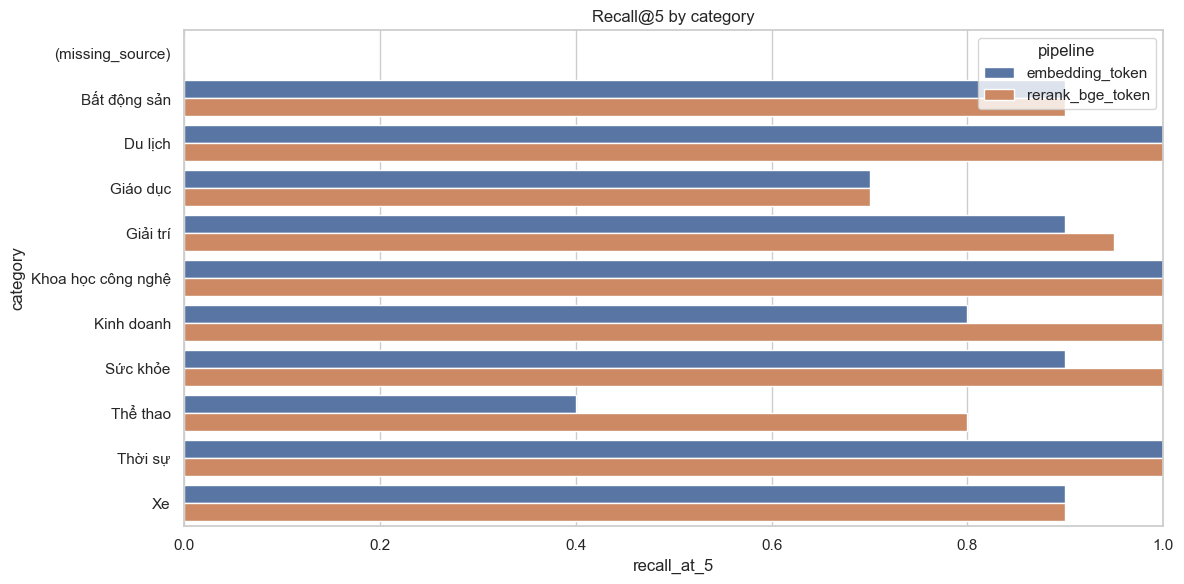

In [9]:
def hit_at_k(row,k=5):
    gold=set(map(str,as_list(row.get('gold_articles',row.get('source_article_ids',[])))))
    cands=row.get('reranked_candidates') or row.get('candidates') or []
    retrieved=set(str(c.get('article_id')) for c in cands[:k])
    return bool(gold & retrieved) if gold else np.nan
def gold_category(row):
    gold=as_list(row.get('gold_articles',row.get('source_article_ids',[])))
    cats=sorted({id_to_category.get(str(x),'(missing_source)') for x in gold})
    return '; '.join(cats) if cats else '(no_gold)'
retrieval_files={'embedding_token':ROOT/'src'/'embedding'/'output'/'per_query_token.jsonl','rerank_bge_token':ROOT/'src'/'re-ranker'/'output_Rerank'/'rerank_token_bge_top5.jsonl'}
recall_tables=[]
for name,path in retrieval_files.items():
    if not path.exists(): print('Missing:',path); continue
    df=pd.DataFrame([json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()])
    df['category']=df.apply(gold_category,axis=1); df['hit_at_5']=df.apply(hit_at_k,axis=1)
    summary=df.groupby('category')['hit_at_5'].agg(questions='count',recall_at_5='mean').reset_index(); summary['pipeline']=name; recall_tables.append(summary)
recall_by_category=pd.concat(recall_tables,ignore_index=True) if recall_tables else pd.DataFrame()
if not recall_by_category.empty:
    recall_by_category['recall_at_5']=recall_by_category['recall_at_5'].round(3)
    display(recall_by_category.sort_values(['pipeline','recall_at_5','category']))
    out=ROOT/'reports'/'eda_outputs'; out.mkdir(parents=True,exist_ok=True)
    recall_by_category.to_csv(out/'recall_at5_by_category.csv',index=False)
    plt.figure(figsize=(12,6)); sns.barplot(data=recall_by_category,y='category',x='recall_at_5',hue='pipeline')
    plt.title('Recall@5 by category'); plt.xlim(0,1); plt.tight_layout()